# 1. Importación de Librerías

In [1]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# 2. Carga de Datos desde Carpeta Local

In [2]:
file_path = 'consumption_history_2019_2020.csv' 

# Cargamos avisando que el separador es ';' y el decimal es ','
df = pd.read_csv(file_path, sep=';', decimal=',')

print(f"Columnas detectadas: {df.columns.tolist()}")
df.head()


Columnas detectadas: ['Data', 'Hora', 'Consumo']


,Data,Hora,Consumo
0,01/01/2019,00:00,27399.64
1,01/01/2019,01:00,26012.17
2,01/01/2019,02:00,24548.73
3,01/01/2019,03:00,23446.89
4,01/01/2019,04:00,22850.35


# 3. Preprocesamiento de la Serie Temporal
Convertimos las fechas y agrupamos por día para tener una serie temporal única.

Registros diarios totales: 578


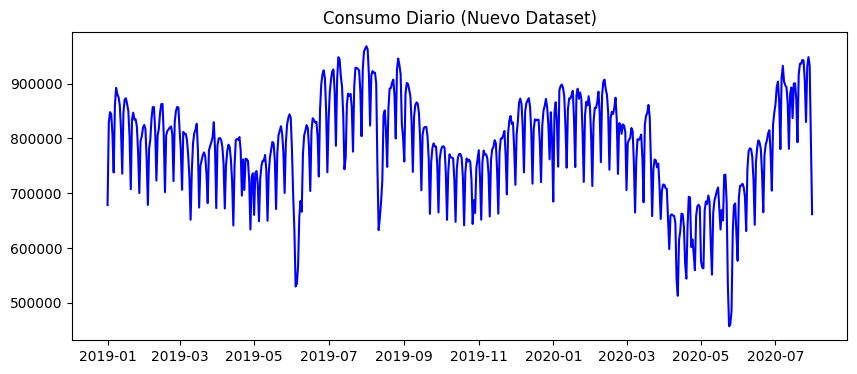

In [3]:
# Convertimos asegurando que el día va primero
df['Data'] = pd.to_datetime(df['Data'], dayfirst=True)

# Agrupamos sumando el consumo diario
df_diario = df.groupby('Data')['Consumo'].sum().reset_index()

# Establecemos el índice y ordenamos
df_diario = df_diario.sort_values('Data')
df_diario.set_index('Data', inplace=True)

print(f"Registros diarios totales: {len(df_diario)}")

# Graficamos los nuevos datos
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(df_diario.index, df_diario['Consumo'], color='blue')
plt.title('Consumo Diario (Nuevo Dataset)')
plt.show(block=False)
plt.close()


# 4. Normalización de los Datos [0, 1]

In [4]:
# Calibración y normalización de datos
from sklearn.preprocessing import MinMaxScaler # Importación forzada por seguridad
scaler = MinMaxScaler()
Data_scaled = scaler.fit_transform(df_diario[['Consumo']])


# 5. Creación de Secuencias (Ventanas de Tiempo)

In [5]:
# Generación de ventanas de tiempo (secuencias)
def create_sequences(Data, window_size):
    X, y = [], []
    for i in range(len(Data) - window_size):
        X.append(Data[i:i+window_size])
        y.append(Data[i+window_size])
    return np.array(X), np.array(y)

# Usaremos una ventana de 12 meses (un año) si los datos son mensuales, 
# o ajusta según la frecuencia de tus datos.
window_size = 1
X, y = create_sequences(Data_scaled, window_size)
print(f"Forma de X (Entradas): {X.shape}, Forma de y (Salida): {y.shape}")

Forma de X (Entradas): (577, 1, 1), Forma de y (Salida): (577, 1)


# 6. División del Dataset (Train/Val/Test)

In [6]:
# División de los datos en entrenamiento, validación y prueba
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f"Entrenamiento: {len(X_train)} | Validación: {len(X_val)} | Prueba: {len(X_test)}")

Entrenamiento: 403 | Validación: 86 | Prueba: 88


# 7. Definición de la Arquitectura LSTM

In [7]:
# Generación de ventanas de tiempo (secuencias)
model = Sequential([
    LSTM(32, input_shape=(window_size, 1), return_sequences=False,
         kernel_regularizer=l2(0.0001)),
    Dropout(0.33),
    Dense(1)
])

model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
model.summary()

c:\Users\Usuario\programacion\bootcampIA\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

# 8. Entrenamiento con Early Stopping

In [8]:
# Entrenamiento de la red neuronal
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1867 - val_loss: 0.0219
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0219 - val_loss: 0.0209
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0185 - val_loss: 0.0223
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0188 - val_loss: 0.0206
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0184 - val_loss: 0.0211
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0175 - val_loss: 0.0202
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0170 - val_loss: 0.0207
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0170 - val_loss: 0.0209
Epoch 9/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0166 - val_loss: 0.0178
Epoch 10/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0181 - val_loss: 0.0178
Epoch 11/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0171 - val_loss: 0.0186
Epoch 12/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

# 9. Evaluación de Resultados
Medimos la precisión de las predicciones en valores originales (sin normalizar).

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

--- Evaluación del modelo ---
MSE: 5200453394.94
MAE: 57594.92
R² Score: 0.62


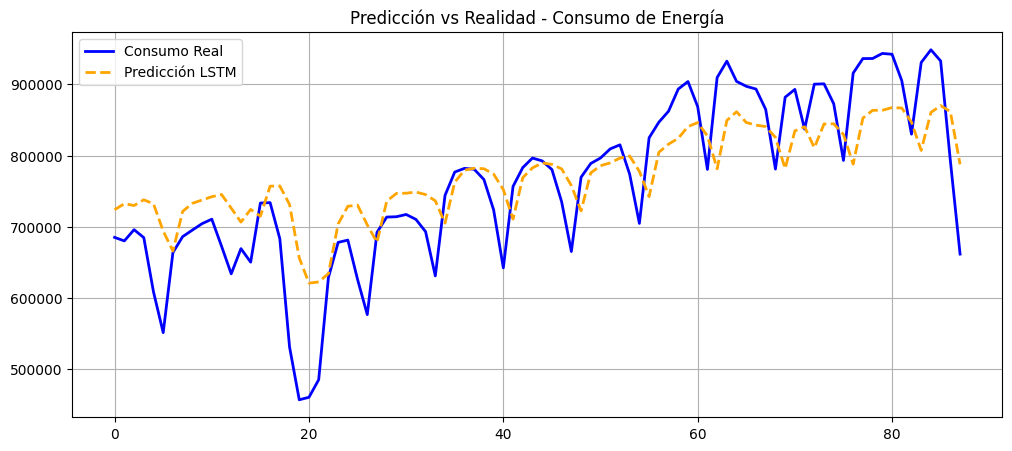

In [9]:
# Visualización de resultados
y_pred = model.predict(X_test)

# Inversa de la normalización para volver a las unidades reales de consumo
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# Cálculo de métricas
mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print("\n--- Evaluación del modelo ---")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

# Gráfico comparativo
plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label='Consumo Real', linewidth=2, color='blue')
plt.plot(y_pred_inv, label='Predicción LSTM', linewidth=2, color='orange', linestyle='--')
plt.title('Predicción vs Realidad - Consumo de Energía')
plt.legend()
plt.grid(True)
plt.show(block=False)
plt.close()

# 10. Variaciones de Hiperparámetros y Generación de Reporte PDF
En esta celda se entrenan 4 variaciones del modelo LSTM variando *Unidades LSTM*, *Learning rate*, *Dropout*, y *Batch size*, además de la regularización L2. Al final de la iteración se guardan los resultados, gráficas de evolución de pérdida y proyecciones en un PDF llamado `reporte_evaluacion_variaciones.pdf`.

In [10]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# 1. Definimos 4 configuraciones de hiperparámetros a probar
hyperparametros = [
    {'unidades_lstm': 16, 'dropout': 0.2, 'learning_rate': 0.01,   'l2': 0.0001, 'batch_size': 8},
    {'unidades_lstm': 32, 'dropout': 0.3, 'learning_rate': 0.001,  'l2': 0.0001, 'batch_size': 4},
    {'unidades_lstm': 64, 'dropout': 0.4, 'learning_rate': 0.0005, 'l2': 0.001,  'batch_size': 8},
    {'unidades_lstm': 32, 'dropout': 0.4, 'learning_rate': 0.001,  'l2': 0.0005, 'batch_size': 16}
]

pdf_filename = 'reporte_evaluacion_variaciones1.pdf'

with PdfPages(pdf_filename) as pdf:
    for i, hp in enumerate(hyperparametros):
        print(f"Entrenando Modelo {i+1}/4 con hiperparámetros: {hp}")
        
        # Construir el modelo
        model_var = Sequential([
            LSTM(hp['unidades_lstm'], input_shape=(window_size, 1), return_sequences=False,
                 kernel_regularizer=l2(hp['l2'])),
            Dropout(hp['dropout']),
            Dense(1)
        ])
        
        model_var.compile(loss='mse', optimizer=Adam(learning_rate=hp['learning_rate']))
        
        # Entrenar el modelo
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        history_var = model_var.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=30, # Limitado a 30 por agilidad
            batch_size=hp['batch_size'],
            callbacks=[early_stop],
            verbose=0 # Silenciar salida por época
        )
        
        # Realizar predicciones y aplicar escala inversa
        preds_scaled = model_var.predict(X_test, verbose=0)
        predicciones = scaler.inverse_transform(preds_scaled)
        realidad = scaler.inverse_transform(y_test)
        
        # Evaluar el modelo
        mse = mean_squared_error(realidad, predicciones)
        mae = mean_absolute_error(realidad, predicciones)
        r2 = r2_score(realidad, predicciones)
        
        # ----- CREAR GRÁFICOS Y TEXTO PARA EL PDF -----
        fig = plt.figure(figsize=(10, 12))
        fig.suptitle(f'Evaluación de Modelo {i+1}', fontsize=16, fontweight='bold')
        
        # 1. Resumen de texto (Hiperparámetros y métricas)
        ax1 = plt.subplot(3, 1, 1)
        ax1.axis('off')
        texto_resumen = (
            f"HIPERPARÁMETROS:\n"
            f"Unidades LSTM: {hp['unidades_lstm']} | Dropout: {hp['dropout']} | "
            f"Learning Rate: {hp['learning_rate']}\n"
            f"Regularización L2: {hp['l2']} | Batch Size: {hp['batch_size']}\n"
            f"\nMÉTRICAS DE EVALUACIÓN (Test Set):\n"
            f"MSE: {mse:.2f} | MAE: {mae:.2f} | R² Score: {r2:.2f}"
        )
        ax1.text(0.1, 0.5, texto_resumen, fontsize=12, verticalalignment='center', 
                 bbox=dict(boxstyle='round,pad=1', facecolor='#f9f9f9', edgecolor='gray'))
        
        # 2. Gráfica de Loss de Entrenamiento y Validación
        ax2 = plt.subplot(3, 1, 2)
        ax2.plot(history_var.history['loss'], label='Entrenamiento (Loss)', marker='o', markersize=3)
        ax2.plot(history_var.history['val_loss'], label='Validación (Val Loss)', marker='o', markersize=3)
        ax2.set_title('Evolución del Error (MSE)')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MSE Escala [0,1]')
        ax2.legend()
        ax2.grid(True, linestyle='--', alpha=0.7)
        
        # 3. Gráfica Predicción vs Realidad
        ax3 = plt.subplot(3, 1, 3)
        ax3.plot(realidad, label='Consumo Real', color='blue', alpha=0.7)
        ax3.plot(predicciones, label='Consumo Predicho', color='red', linestyle='--', alpha=0.9)
        ax3.set_title('Predicción vs Consumo Real en Datos de Prueba')
        ax3.set_xlabel('Días (Conjunto de Prueba)')
        ax3.set_ylabel('Consumo Eléctrico')
        ax3.legend()
        ax3.grid(True, linestyle='--', alpha=0.7)
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        
        # Guardar página en el PDF
        pdf.savefig(fig)
        plt.close(fig)
        print(f"-> Modelo {i+1} guardado en el reporte.\n")
        
print(f"\n¡El archivo {pdf_filename} ha sido creado con éxito!")


Entrenando Modelo 1/4 con hiperparámetros: {'unidades_lstm': 16, 'dropout': 0.2, 'learning_rate': 0.01, 'l2': 0.0001, 'batch_size': 8}


c:\Users\Usuario\programacion\bootcampIA\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


-> Modelo 1 guardado en el reporte.

Entrenando Modelo 2/4 con hiperparámetros: {'unidades_lstm': 32, 'dropout': 0.3, 'learning_rate': 0.001, 'l2': 0.0001, 'batch_size': 4}


c:\Users\Usuario\programacion\bootcampIA\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


-> Modelo 2 guardado en el reporte.

Entrenando Modelo 3/4 con hiperparámetros: {'unidades_lstm': 64, 'dropout': 0.4, 'learning_rate': 0.0005, 'l2': 0.001, 'batch_size': 8}


c:\Users\Usuario\programacion\bootcampIA\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


-> Modelo 3 guardado en el reporte.

Entrenando Modelo 4/4 con hiperparámetros: {'unidades_lstm': 32, 'dropout': 0.4, 'learning_rate': 0.001, 'l2': 0.0005, 'batch_size': 16}


c:\Users\Usuario\programacion\bootcampIA\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


-> Modelo 4 guardado en el reporte.


¡El archivo reporte_evaluacion_variaciones1.pdf ha sido creado con éxito!
